In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore")

In [34]:
df = pd.read_csv('Diabetes.csv')

In [35]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [33]:
df = df.drop(columns = ['Outcome'])

In [10]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
5,5,116,74,0,0,25.6,0.201,30
6,3,78,50,32,88,31.0,0.248,26
7,10,115,0,0,0,35.3,0.134,29
8,2,197,70,45,543,30.5,0.158,53
9,8,125,96,0,0,0.0,0.232,54


In [11]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

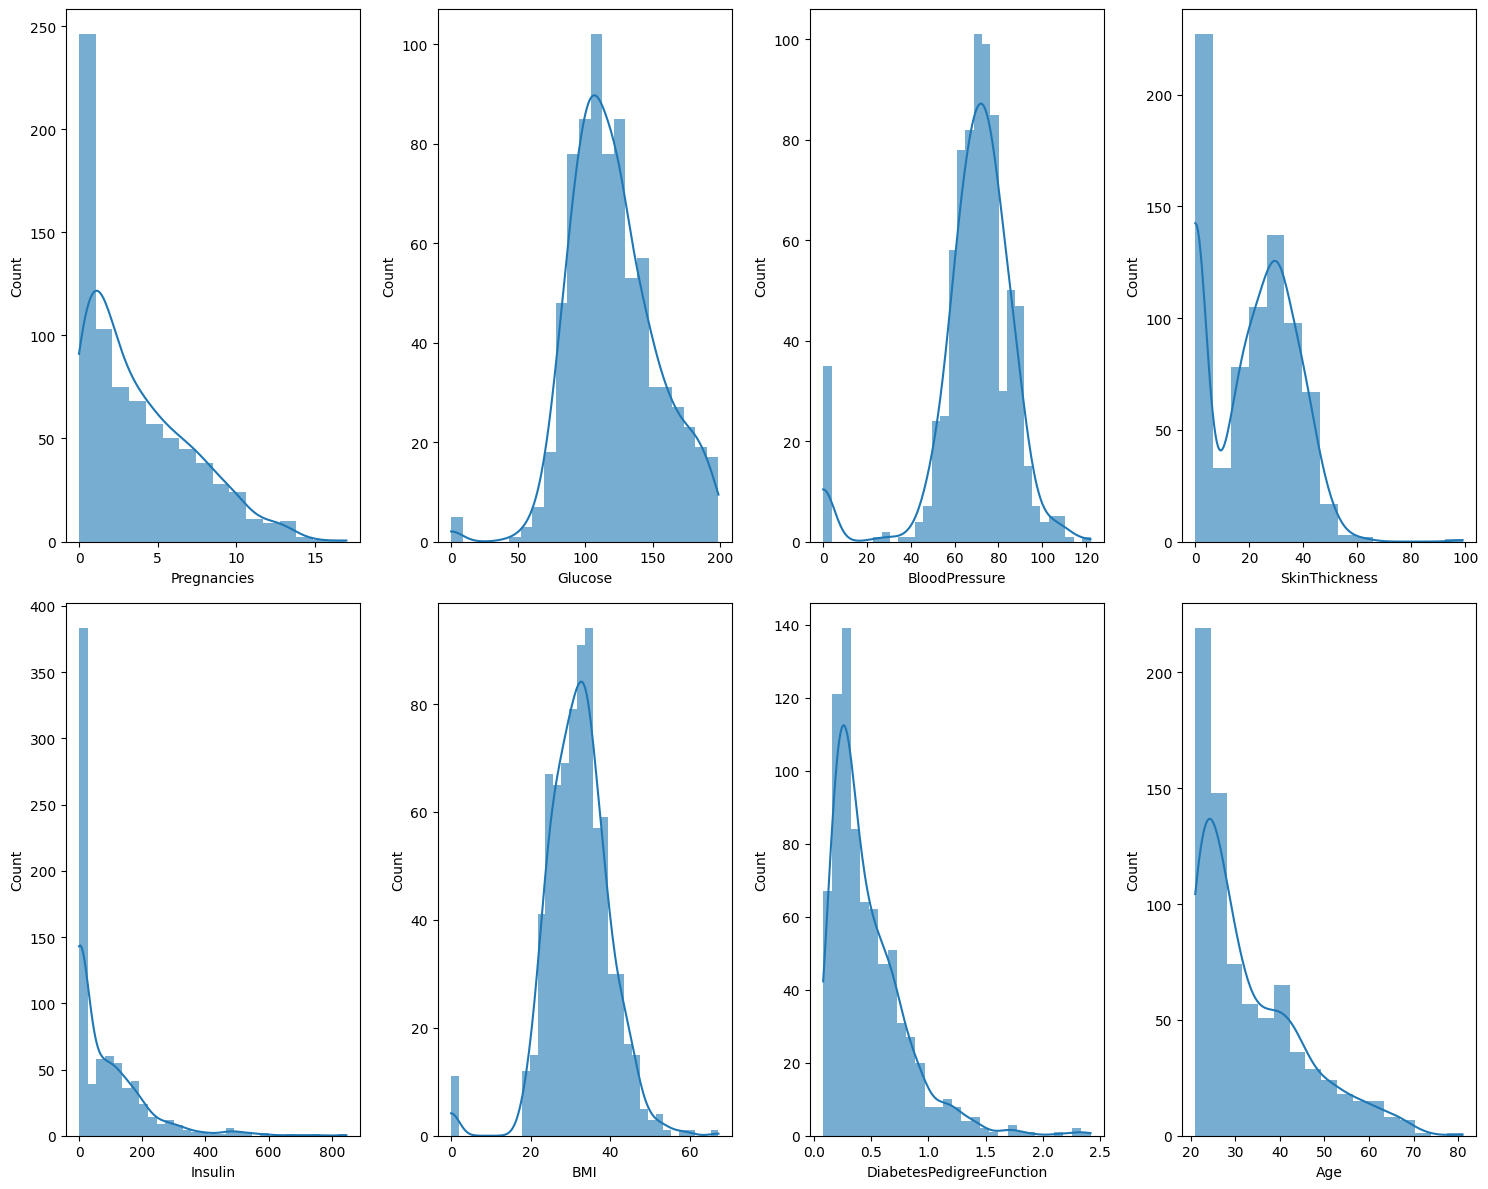

In [19]:
plt.figure(figsize = (15,12))
for i in range(len(df.columns)):
    plt.subplot(2,4,i+1)
    sns.histplot(df[df.columns[i]], kde = True, edgecolor = None, alpha = 0.6)

plt.tight_layout()
plt.show()

In [20]:
df['Pregnancies']                 = df['Pregnancies'].replace(0, df['Pregnancies'].median())
df['Glucose']                     = df['Glucose'].replace(0, df['Glucose'].mean())
df['BloodPressure']               = df['BloodPressure'].replace(0, df['BloodPressure'].mean())
df['SkinThickness']               = df['SkinThickness'].replace(0, df['SkinThickness'].mean())
df['Insulin']                     = df['Insulin'].replace(0, df['Insulin'].median())
df['BMI']                         = df['BMI'].replace(0, df['BMI'].mean())
df['DiabetesPedigreeFunction']    = df['DiabetesPedigreeFunction'].replace(0, df['DiabetesPedigreeFunction'].median())
df['Age']                         = df['Age'].replace(0, df['Age'].median())

<Axes: >

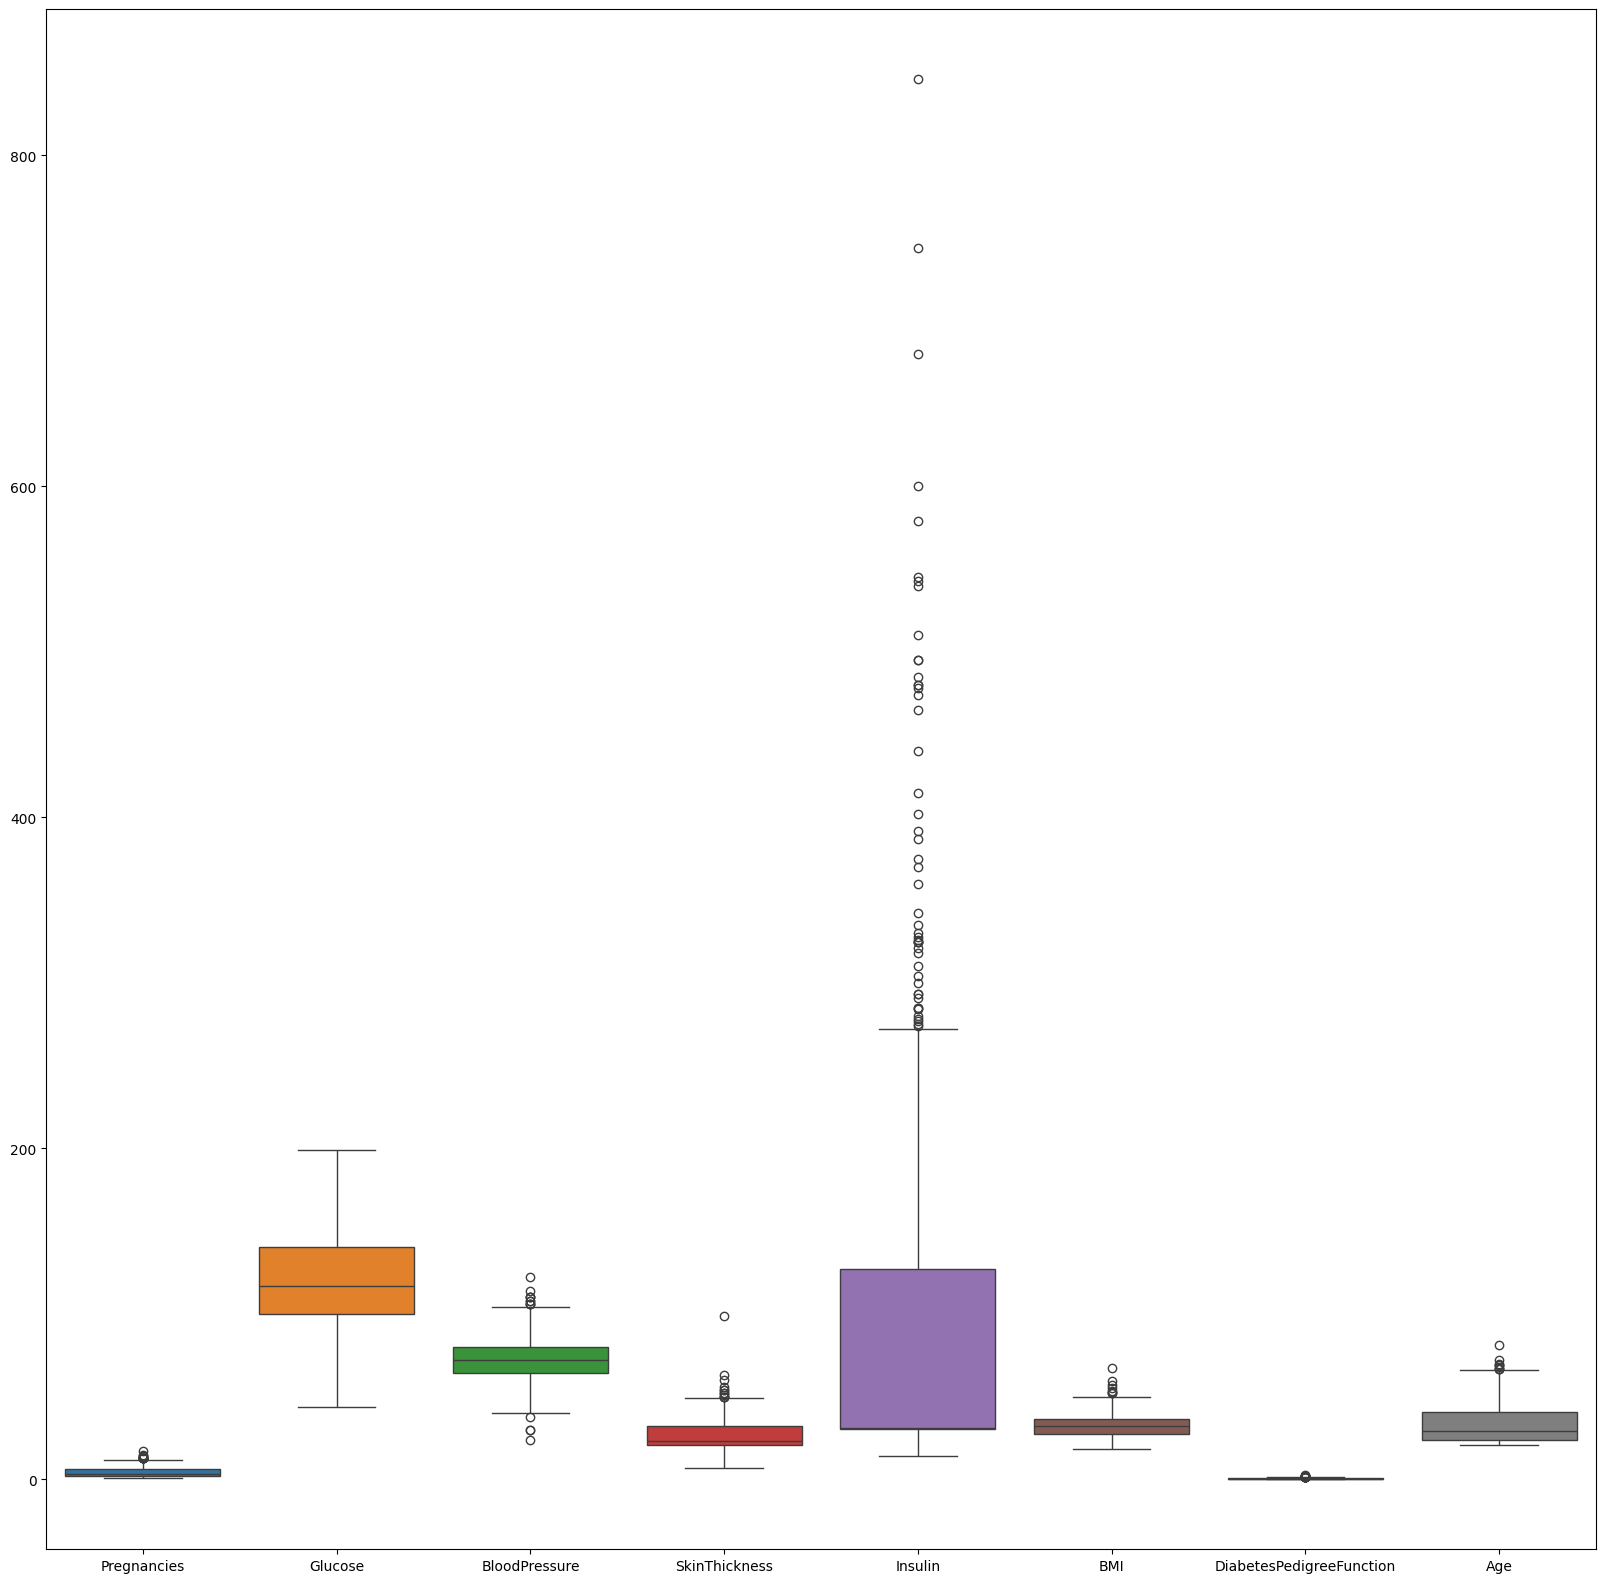

In [21]:
plt.figure(figsize = (20,20))
sns.boxplot(df)

In [22]:
q1 = df['Insulin'].quantile(0.25)
q3 = df['Insulin'].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr
data_without_outliers = (df['Insulin'] > lower_limit) & (df['Insulin'] < upper_limit)

df = df[data_without_outliers]

<Axes: >

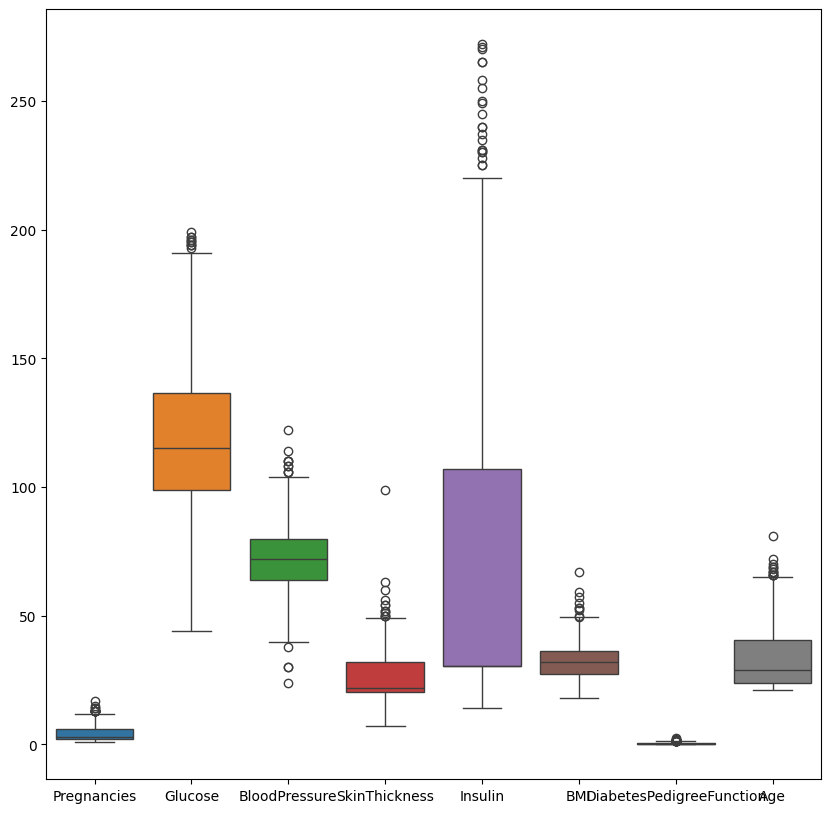

In [23]:
plt.figure(figsize = (10,10))
sns.boxplot(df)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df = scaler.fit_transform(df)

<Axes: >

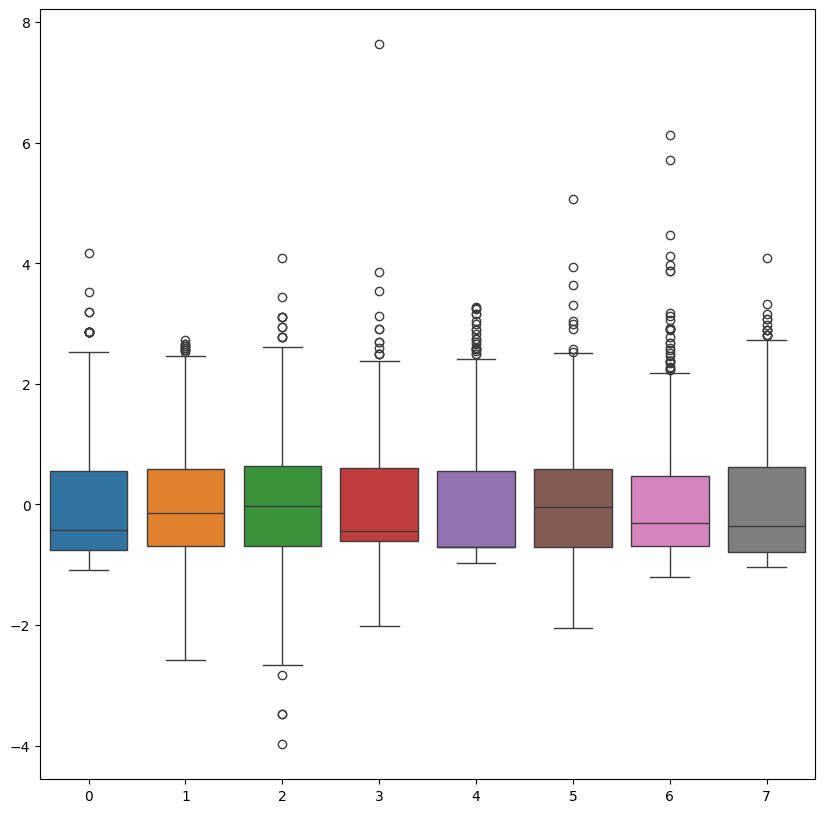

In [25]:
plt.figure(figsize = (10,10))
sns.boxplot(df)

In [26]:
df = pd.DataFrame(df)

In [27]:
df.describe()

,0,1,2,3,4,5,6,7
count,7.190000e+02,7.190000e+02,7.190000e+02,7.190000e+02,7.190000e+02,7.190000e+02,7.190000e+02,7.190000e+02
mean,1.408238e-16,-1.432944e-16,4.101185e-16,3.310596e-16,-7.905900e-17,2.767065e-16,-9.882375e-18,-9.635315e-17
std,1.000696e+00,1.000696e+00,1.000696e+00,1.000696e+00,1.000696e+00,1.000696e+00,1.000696e+00,1.000696e+00
min,-1.081523e+00,-2.576935e+00,-3.979540e+00,-2.024033e+00,-9.795016e-01,-2.045540e+00,-1.211677e+00,-1.044482e+00
25%,-7.528603e-01,-6.935558e-01,-6.836641e-01,-6.030092e-01,-7.076368e-01,-7.089259e-01,-6.977084e-01,-7.874430e-01
50%,-4.241982e-01,-1.456636e-01,-2.448889e-02,-4.493702e-01,-7.076368e-01,-4.061862e-02,-3.090979e-01,-3.590444e-01
75%,5.617883e-01,5.905667e-01,6.346863e-01,6.004047e-01,5.528273e-01,5.841034e-01,4.665563e-01,6.262722e-01
max,4.177072e+00,2.730771e+00,4.095356e+00,7.633897e+00,3.271475e+00,5.058856e+00,6.128048e+00,4.096300e+00


In [28]:
df.shape

(719, 8)

In [30]:
df.corr()

,0,1,2,3,4,5,6,7
0,1.000000,0.171065,0.246954,0.036116,-0.070004,0.087543,-0.006897,0.530693
1,0.171065,1.000000,0.250770,0.112466,0.199624,0.215513,0.111730,0.283620
2,0.246954,0.250770,1.000000,0.125836,-0.022088,0.281039,-0.000727,0.330982
3,0.036116,0.112466,0.125836,1.000000,0.297924,0.524416,0.144989,0.023621
4,-0.070004,0.199624,-0.022088,0.297924,1.000000,0.192581,0.183717,-0.070775
5,0.087543,0.215513,0.281039,0.524416,0.192581,1.000000,0.161856,0.038808
6,-0.006897,0.111730,-0.000727,0.144989,0.183717,0.161856,1.000000,0.051551
7,0.530693,0.283620,0.330982,0.023621,-0.070775,0.038808,0.051551,1.000000


In [21]:
eigenvalues, eigenvectors = np.linalg.eig(covariance)

In [22]:
eigenvalues

array([2.1789338 , 1.67153237, 0.39268351, 0.48189762, 1.00743615,
       0.86361782, 0.78986169, 0.62517909])

In [23]:
eigenvectors

array([[ 0.34679673,  0.44431192,  0.34983401, -0.52715915,  0.04795956,
        -0.23960241, -0.47069616, -0.02782167],
       [ 0.39896323,  0.04360622,  0.20000075, -0.00525599,  0.33434752,
         0.58927129,  0.25474026, -0.52438287],
       [ 0.40570118,  0.21152732,  0.21604061,  0.01113377, -0.31191483,
         0.13080761,  0.51251351,  0.60563491],
       [ 0.37109463, -0.4175346 ,  0.43580743,  0.50675368, -0.31736391,
        -0.18152254, -0.29593561, -0.14134376],
       [ 0.21145504, -0.43867838, -0.14995156, -0.12506752,  0.35737682,
         0.38346797, -0.4194017 ,  0.52350457],
       [ 0.43502351, -0.32599072, -0.54217478, -0.41175818, -0.38529396,
        -0.13909359,  0.11695379, -0.243946  ],
       [ 0.19114543, -0.25114825,  0.09767703, -0.0272412 ,  0.61641421,
        -0.60551019,  0.37455412,  0.05661481],
       [ 0.38439619,  0.46885217, -0.52443726,  0.52841611,  0.17822682,
        -0.11068723, -0.18286   ,  0.02655064]])

In [25]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 3)
pca.fit_transform(df)

array([[ 1.50199872,  0.70051104,  0.31675902],
       [-1.59641418, -0.1797751 , -0.56072784],
       [ 0.16038821,  1.26868162,  1.82510755],
       ...,
       [-0.51960408,  0.29878705,  0.24243362],
       [-0.81959368,  0.62639094,  0.38940737],
       [-1.32036988, -0.65878274, -1.0429918 ]])

In [27]:
pca1 = df @ eigenvectors[:, 0]
pca1

0      1.501999
1     -1.596414
2      0.160388
3     -1.899038
4      1.454662
         ...   
714    2.587578
715   -0.414816
716   -0.519604
717   -0.819594
718   -1.320370
Length: 719, dtype: float64

In [28]:
pca2 = df @ eigenvectors[:, 1]
pca2

0      0.700511
1     -0.179775
2      1.268682
3     -0.697716
4     -3.745771
         ...   
714    0.548059
715   -0.456229
716    0.298787
717    0.626391
718   -0.658783
Length: 719, dtype: float64

In [29]:
pca3 = df @ eigenvectors[:, 4]
pca3

0      0.316759
1     -0.560728
2      1.825108
3     -0.533247
4      4.192973
         ...   
714   -0.457110
715   -0.810816
716    0.242434
717    0.389407
718   -1.042992
Length: 719, dtype: float64

In [31]:
pca.explained_variance_ratio_

array([0.27198791, 0.20865095, 0.12575437])

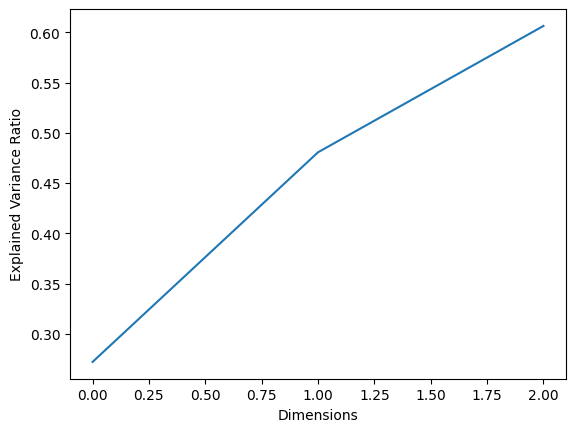

In [33]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Dimensions')
plt.ylabel('Explained Variance Ratio')
plt.show()